# import

In [1]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm


# 乱数の固定

In [2]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True


# （可能なら）GPUの利用

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# 汎用関数の定義

## func show_images_labels

In [41]:
# イメージとラベル表示
def show_images_labels(loader, classes, net, device):
    # データローダーから最初の1セットを取得する
    for images, labels in loader:
        break
    # 表示数は50個とバッチサイズのうち小さい方
    n_size = min(images.size(0), 50)

    if net is not None:
        # デバイスの割り当て
        inputs = images.to(device)
        labels = labels.to(device)

      # 予測計算
        outputs = net(inputs)
        predicted = torch.max(outputs,1)[1]
        #images = images.to('cpu')

    # 最初のn_size個の表示
    plt.figure(figsize=(20, 15))
    for i in range(n_size):
        ax = plt.subplot(5, 10, i + 1)
        label_name = classes[labels[i]]
        # netがNoneでない場合は、予測結果もタイトルに表示する
        if net is not None:
            predicted_name = classes[predicted[i]]
            # 正解かどうかで色分けをする
            if label_name == predicted_name:
                c = 'g'
            else:
                c = 'r'
            ax.set_title(label_name + ':' + predicted_name, c=c, fontsize=20)
        # netがNoneの場合は、正解ラベルのみ表示
        else:
            ax.set_title(label_name, fontsize=20)
        # TensorをNumPyに変換
        image_np = images[i].numpy().copy()
        #print(image_np.shape)
        # 軸の順番変更 (channel, row, column) -> (row, column, channel)
        img = np.transpose(image_np, (1, 2, 0))
        # 値の範囲を[-1, 1] -> [0, 1]に戻す
        img = (img + 1)/2
        # 結果表示
        plt.imshow(img)
        ax.set_axis_off()
    plt.show()


## func evaluate_history

In [5]:
def evaluate_history(history):
    print(f'初期状態: 損失: {history[0, 3]:.5f} 精度: {history[0, 4]:.5f}') 
    print(f'最終状態: 損失: {history[-1, 3]:.5f} 精度: {history[-1, 4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    plt.figure(figsize=(9, 8))
    plt.plot(history[:, 0], history[:, 1], 'r', label='train')
    plt.plot(history[:, 0], history[:, 3], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Learning Curve (Loss)')
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(9,8))
    plt.plot(history[:, 0], history[:, 2], 'r', label='train')
    plt.plot(history[:, 0], history[:, 4], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Learning Curve (Accuracy)')
    plt.grid()
    plt.legend()
    plt.show()


# MLP
まずは，MLPでCIFAR-10に突撃してみる．

## データ準備

### Transformsの定義
データ範囲を$[0, 1]$から$[-1, 1]$へ変換したいものとする．
`Normalize(μ, σ)`は，元のデータ$x$を$X = (x - \mu) / \sigma$へ変換する．

In [6]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5), # [0, 1] -> [-1, 1]
    transforms.Lambda(lambda x: x.view(-1))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5), # [0, 1] -> [-1, 1]
    transforms.Lambda(lambda x: x.view(-1))
])


### データセットの定義
Transformsを後から変更するのが危険なので，こんなまどろっこしい書き方をします．

In [7]:
data_root = './data'

# 初期化時にTransformsを設定した，元になるデータセットを作る．
train_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)
valid_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=eval_transform)

train_size = int(len(train_set_full) * 0.9)
valid_size = len(train_set_full) - train_size

# データを分割するためのランダムなインデックスを作成
indices = torch.randperm(len(train_set_full)).tolist()

train_set = Subset(train_set_full, indices[:train_size])
valid_set = Subset(valid_set_full, indices[train_size:])
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=eval_transform)

print(len(train_set))
print(len(valid_set))
print(len(test_set))


100%|██████████| 170M/170M [00:05<00:00, 33.3MB/s] 


45000
5000
10000


### データセットの確認

In [8]:
image, label = train_set[0]
print("3 * 32 * 32 =", 3 * 32 * 32)
print(image.shape)
print(label)


3 * 32 * 32 = 3072
torch.Size([3072])
6


### データローダーの定義
データローダーを使うと，for文でミニバッチを取り出す事ができるよね．

In [9]:
batch_size = 100 # ミニバッチのサイズ指定

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# データローダーから先頭のミニバッチを取得してみる．
for loader in [train_loader, valid_loader, test_loader]:
    for images, labels in loader:
        print(f"images.shape: {images.shape}, labels.shape: {labels.shape}")
        break


images.shape: torch.Size([100, 3072]), labels.shape: torch.Size([100])
images.shape: torch.Size([100, 3072]), labels.shape: torch.Size([100])
images.shape: torch.Size([100, 3072]), labels.shape: torch.Size([100])


### 正解ラベルの変換規則

In [10]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## モデル定義
3072入力10出力1隠れ層のニューラルネットワークモデル

### 次元数の定義

In [11]:
n_input = images[0].shape[0]
n_output = len(classes)
n_hidden = 128

print(n_input)
print(n_output)
print(n_hidden)


3072
10
128


### モデルのクラスを定義

In [12]:
class Net(nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()

        self.l1 = nn.Linear(n_input, n_hidden)
        self.l2 = nn.Linear(n_hidden, n_output)
        self.relu = nn.ReLU(inplace=True) # 中間テンソルを上書きしてメモリ節約

    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.relu(x1)
        x3 = self.l2(x2)
        return x3


## 学習

### 初期設定

In [13]:
num_epochs = 50

# 予測計算用
net = Net(n_input=n_input, n_output=n_output, n_hidden=n_hidden).to(device)

# 損失計算用
criterion = nn.CrossEntropyLoss()

# パラメータ更新用
lr = 0.01
optimizer = optim.SGD(params=net.parameters(), lr=lr)

# 記録用
history = np.zeros((0, 5)) # epoch, loss (train), acc (train), loss (valid), acc (valid)


### 学習ループ

In [14]:
for epoch in range(num_epochs):
    train_loss_sum, train_acc_sum, n_train = 0, 0, 0
    valid_loss_sum, valid_acc_sum, n_valid = 0, 0, 0

    # 訓練フェーズ
    net.train()
    for images, labels in tqdm(train_loader):
        batch_size = images.size(0)
        n_train += batch_size

        # GPUに送る．
        inputs = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 勾配の初期化
        outputs = net(inputs) # 予測計算
        loss = criterion(outputs, labels) # 損失計算
        loss.backward() # 勾配計算
        optimizer.step() # パラメータ更新

        # lossはバッチサイズで平均が取られているため平均前の損失に戻して加算
        train_loss_sum += loss.item() * batch_size
        values, indices = torch.max(outputs, dim=1)
        train_acc_sum += (indices == labels).sum().item()

    # 検証フェーズ
    net.eval()
    with torch.no_grad():
        for images, labels in valid_loader:
            batch_size = images.size(0)
            n_valid += batch_size

            # GPUに送る．
            inputs = images.to(device)
            labels = labels.to(device)

            outputs = net(inputs) # 予測計算
            loss = criterion(outputs, labels) # 損失計算

            # lossはバッチサイズで平均が取られているため平均前の損失に戻して加算
            valid_loss_sum += loss.item() * batch_size
            values, indices = torch.max(outputs, dim=1)
            valid_acc_sum += (indices == labels).sum().item()

    # 記録フェーズ
    train_loss = train_loss_sum / n_train
    train_acc = train_acc_sum / n_train

    valid_loss = valid_loss_sum / n_valid
    valid_acc = valid_acc_sum / n_valid

    print(f"epoch: {epoch}/{num_epochs}, train_loss: {train_loss}, train_acc: {train_acc}, valid_loss: {valid_loss}, valid_acc: {valid_acc}")
    item = np.array([epoch, train_loss, train_acc, valid_loss, valid_acc])
    history = np.vstack((history, item))


  0%|          | 0/450 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 評価

初期状態: 損失: 1.81615 精度: 0.37220
最終状態: 損失: 1.37509 精度: 0.52620


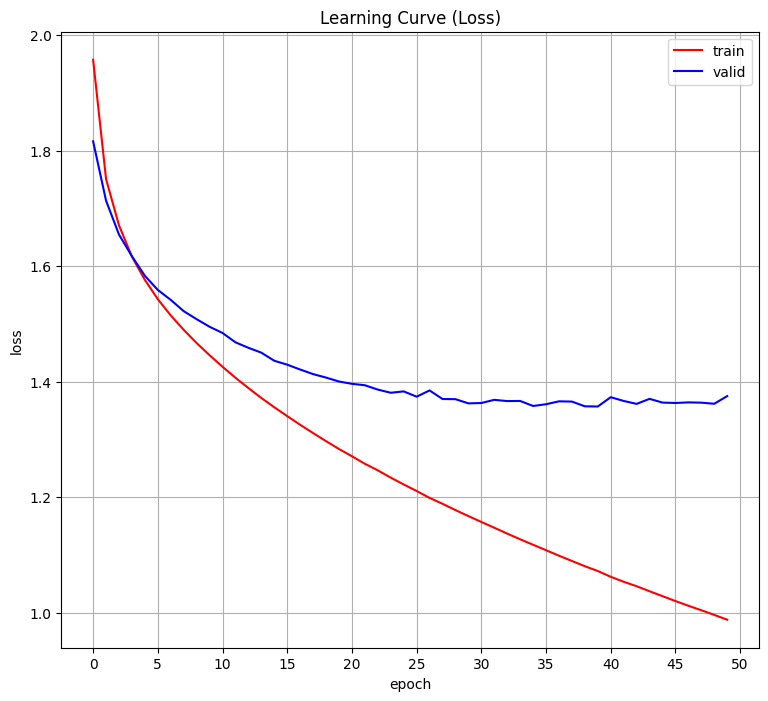

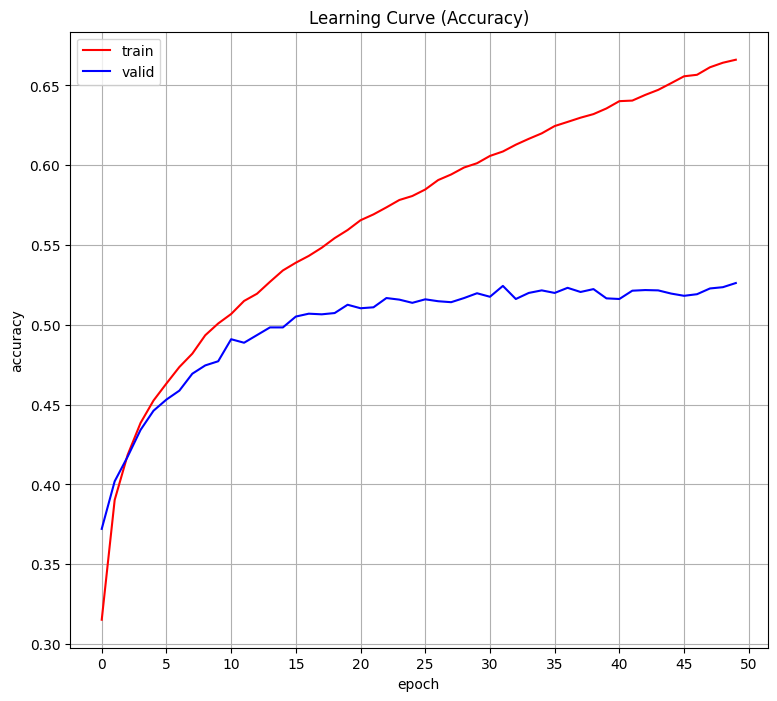

In [ ]:
evaluate_history(history)


# CNN

## データ準備

### Transformsの定義

In [52]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])


### データセットの定義

In [53]:
data_root = './data'

# 元になるデータセット
train_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)
valid_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=eval_transform)

train_size = int(len(train_set_full) * 0.9)
valid_size = len(train_set_full) - train_size

# データを分割するためのランダムなインデックスを生成
indices = torch.randperm(len(train_set_full)).tolist()

train_set = Subset(train_set_full, indices[:train_size])
valid_set = Subset(valid_set_full, indices[train_size:])
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=eval_transform)

print(len(train_set))
print(len(valid_set))
print(len(test_set))


45000
5000
10000


### データセットの確認

In [54]:
image, label = train_set[0]
print(image.shape)
print(label)


torch.Size([3, 32, 32])
7


### データローダーの定義

In [55]:
# from torch.utils.data import Dataloader

# ミニバッチのサイズ指定
batch_size = 100

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# データローダーから先頭のミニバッチを取得してみる．
for loader in [train_loader, valid_loader, test_loader]:
    for images, labels in loader:
        print(f"images.shape: {images.shape}, labels.shape: {labels.shape}")
        break


images.shape: torch.Size([100, 3, 32, 32]), labels.shape: torch.Size([100])
images.shape: torch.Size([100, 3, 32, 32]), labels.shape: torch.Size([100])
images.shape: torch.Size([100, 3, 32, 32]), labels.shape: torch.Size([100])


### 正解ラベルの変換規則

In [56]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## モデル定義

### 次元数の定義

In [57]:
n_output = len(classes)
n_hidden = 128

print(n_output)
print(n_hidden)


10
128


### モデルのクラスを定義

In [58]:
class CNN(nn.Module):
    def __init__(self, n_output, n_hidden):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 32, 3)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d((2, 2))
        self.flatten = nn.Flatten()
        self.l1 = nn.Linear(6272, n_hidden) # 32チャンネル * 14ピクセル * 14ピクセル = 6272
        self.l2 = nn.Linear(n_hidden, n_output)

        self.features = nn.Sequential(
            self.conv1,
            self.relu,
            self.conv2,
            self.relu,
            self.maxpool
        )

        self.classifier = nn.Sequential(
            self.l1,
            self.relu,
            self.l2
        )
    
    def forward(self, x):
        x1 = self.features(x)
        x2 = self.flatten(x1)
        x3 = self.classifier(x2)
        return x3


## 学習

### 初期設定

In [59]:
num_epochs = 50

# 予測計算用
net = CNN(n_output=n_output, n_hidden=n_hidden).to(device)

# 損失計算用
criterion = nn.CrossEntropyLoss()

# パラメータ更新用
lr = 0.01
optimizer = optim.SGD(params=net.parameters(), lr=lr)

# 記録用
history = np.zeros((0, 5)) # epoch, loss (train), acc (train), loss (valid), acc (valid)


### 学習ループ

In [60]:
for epoch in tqdm(range(num_epochs)):
    train_loss, train_acc, n_train = 0, 0, 0
    valid_loss, valid_acc, n_valid = 0, 0, 0

    # 訓練フェーズ
    net.train()
    for images, labels in train_loader:
        batch_size = images.size(0)
        n_train += batch_size

        inputs = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 勾配の初期化
        outputs = net(inputs) # 予測計算
        loss = criterion(outputs, labels) # 損失計算
        loss.backward() # 勾配計算
        optimizer.step() # パラメータ更新

        train_loss += loss.item() * batch_size # 損失はバッチサイズで平均されているため戻しておく．
        _, indices = torch.max(outputs, dim=1)
        train_acc += (indices == labels).sum().item()

    # 検証フェーズ
    net.eval()
    with torch.no_grad():
        for images, labels in valid_loader:
            batch_size = images.size(0)
            n_valid += batch_size

            inputs = images.to(device)
            labels = labels.to(device)

            outputs = net(inputs) # 予測計算
            loss = criterion(outputs, labels) # 損失計算

            valid_loss += loss.item() * batch_size # 損失はバッチサイズで平均されているため戻しておく．
            _, indices = torch.max(outputs, dim=1)
            valid_acc += (indices == labels).sum().item()

    # 記録フェーズ
    train_loss /= n_train
    train_acc /= n_train

    valid_loss /= n_valid
    valid_acc /= n_valid

    print(f"epoch: {epoch}/{num_epochs}, train_loss: {train_loss}, train_acc: {train_acc}, valid_loss: {valid_loss}, valid_acc: {valid_acc}")
    item = np.array([epoch, train_loss, train_acc, valid_loss, valid_acc])
    history = np.vstack((history, item))


  0%|          | 0/50 [00:00<?, ?it/s]

epoch: 0/50, train_loss: 2.111371552679274, train_acc: 0.2446222222222222, valid_loss: 1.9069971466064453, valid_acc: 0.3236
epoch: 1/50, train_loss: 1.783508227666219, train_acc: 0.36993333333333334, valid_loss: 1.701069438457489, valid_acc: 0.3948
epoch: 2/50, train_loss: 1.613652389579349, train_acc: 0.42775555555555556, valid_loss: 1.5478876948356628, valid_acc: 0.4484
epoch: 3/50, train_loss: 1.4836016292042202, train_acc: 0.4706, valid_loss: 1.4813927555084228, valid_acc: 0.4768
epoch: 4/50, train_loss: 1.3970374274253845, train_acc: 0.5023555555555556, valid_loss: 1.3730336427688599, valid_acc: 0.5068
epoch: 5/50, train_loss: 1.328512997892168, train_acc: 0.5281333333333333, valid_loss: 1.3158833646774293, valid_acc: 0.528
epoch: 6/50, train_loss: 1.2689967057440017, train_acc: 0.5498222222222222, valid_loss: 1.2940665316581725, valid_acc: 0.5278
epoch: 7/50, train_loss: 1.2182986321714189, train_acc: 0.5701555555555555, valid_loss: 1.2404632091522216, valid_acc: 0.5614
epoch: 8

## 評価

初期状態: 損失: 1.90700 精度: 0.32360
最終状態: 損失: 1.85802 精度: 0.65320


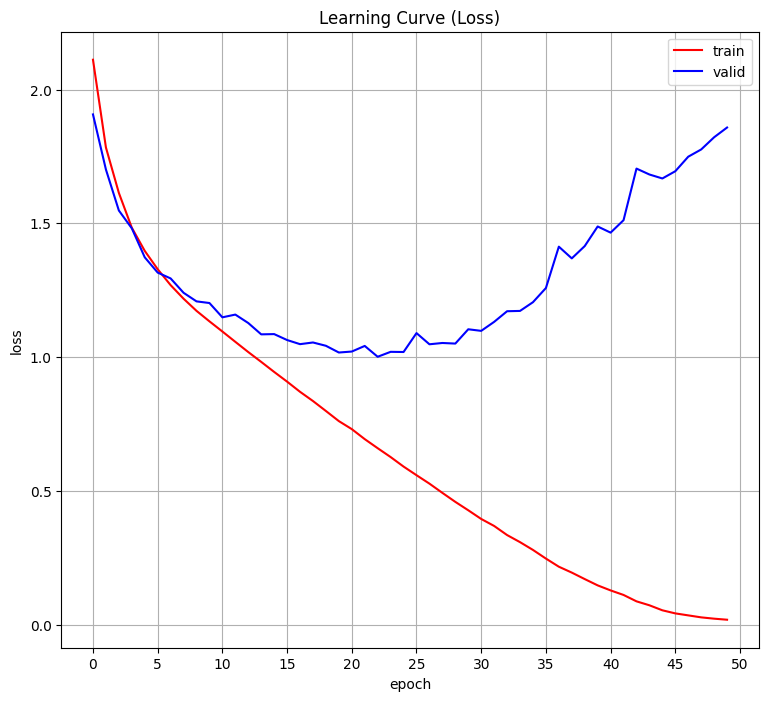

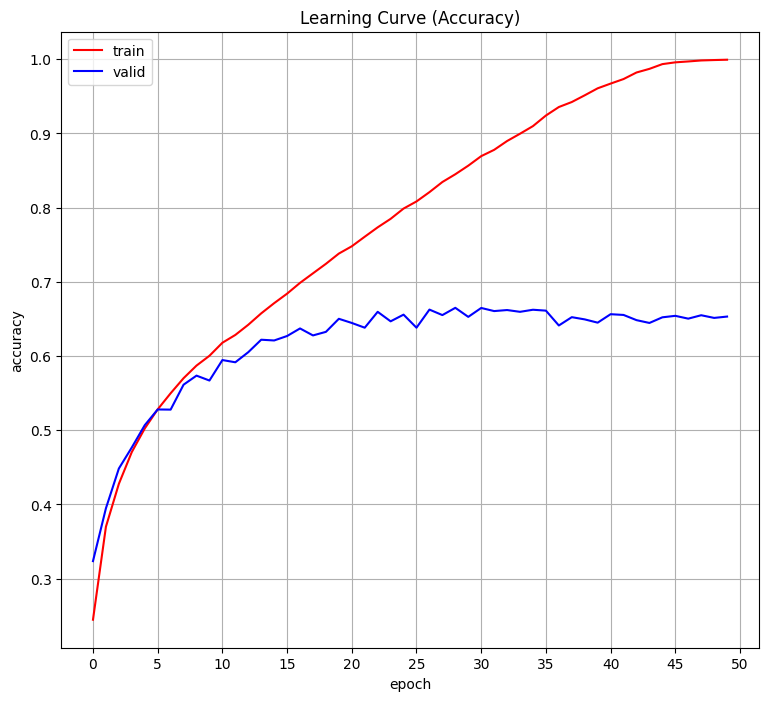

In [61]:
evaluate_history(history)


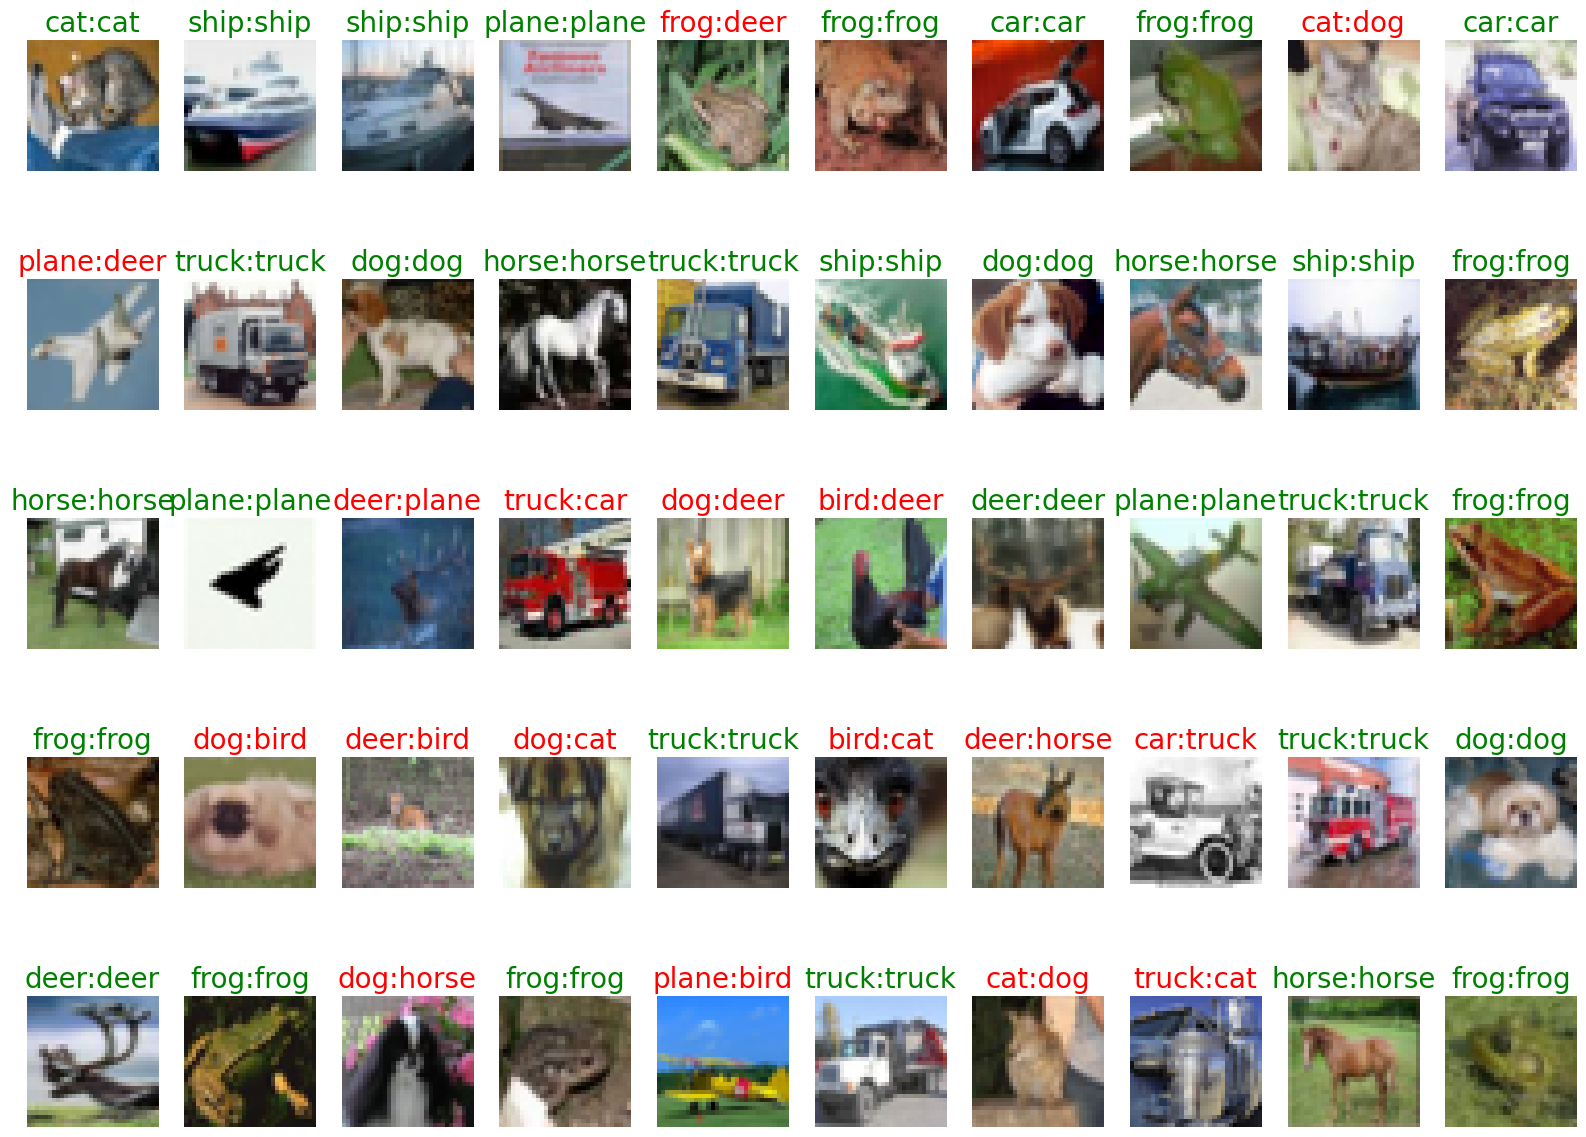

In [62]:
# 最初の50個の表示
show_images_labels(test_loader, classes, net, device)


# 線形分離可能な特徴空間が幻出する過程の可視化（ニューラル崩壊もどき）

In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# 乱数シードの固定（再現性のため）
torch.manual_seed(42)

# --- 1. 宇宙（モデル）の設定 ---
C = 4       # クラス数（3次元空間で最も美しく反発し合うのは4クラス＝正四面体）
N = 20      # 各クラスの衛星（特徴ベクトル）の数
dim = 3     # 3次元宇宙

# 正解ラベル（0, 1, 2, 3 がそれぞれ20個ずつ）
labels = torch.arange(C).repeat_interleave(N)

# 【ここがポイント！】
# CNNがない代わりに、特徴ベクトル X 自身を「動かせるパラメータ」にする
# 初期状態：原点付近にデタラメに散らばった星屑
X = torch.randn(C * N, dim) * 0.1
X.requires_grad_(True)

# 重みベクトル W（惑星）も動かせるパラメータ
# 初期状態：デタラメな配置
W = torch.randn(C, dim)
W.requires_grad_(True)

# 最適化手法（Adam）
# weight_decay (L2正則化) は宇宙の「ゴムひも」の役割。
# これがないと無限の彼方へ飛んでいってしまうため、中心に引き留める力を加える。
optimizer = torch.optim.Adam([X, W], lr=0.05, weight_decay=1e-2)
# optimizer = torch.optim.SGD([X, W], lr=1.0, momentum=0.9) # SGDでもできるぅ！

epochs = 150
history_X = []
history_W = []

print("宇宙の歴史（学習）を計算中...")

# --- 2. 物理演算（学習）ループ ---
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # 内積（類似度）の計算: XとWのドット積
    logits = X @ W.T
    
    # 損失関数（引力と斥力の発生源）
    loss = F.cross_entropy(logits, labels)
    loss.backward()
    
    optimizer.step()
    
    # 軌跡を記録
    history_X.append(X.detach().clone().numpy())
    history_W.append(W.detach().clone().numpy())

print("計算完了！アニメーションを生成します...")

# --- 3. アニメーション（可視化）の作成 ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'green', 'blue', 'purple']

def update(frame):
    ax.clear()
    
    # 宇宙の枠を固定
    limit = 2.0
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_title(f"Neural Collapse in 3D Space (Epoch {frame:03d})", fontsize=14)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    
    curr_X = history_X[frame]
    curr_W = history_W[frame]
    
    # クラスごとに描画
    for c in range(C):
        idx = (labels.numpy() == c)
        
        # 衛星（特徴ベクトル x）を描画
        ax.scatter(curr_X[idx, 0], curr_X[idx, 1], curr_X[idx, 2], 
                   c=colors[c], s=20, alpha=0.6)
        
        # 惑星（重みベクトル w）を原点からの直線として描画
        ax.plot([0, curr_W[c, 0]], [0, curr_W[c, 1]], [0, curr_W[c, 2]], 
                color=colors[c], linewidth=4, label=f'Class {c} Weight')
    
    ax.legend()

# アニメーションの作成
anim = animation.FuncAnimation(fig, update, frames=epochs, interval=50)

# GIFとして保存（※要 pillow）
anim.save('neural_collapse_3d.gif', writer='pillow', fps=20)
print("『neural_collapse_3d.gif』として保存されました！")

# 画面にも表示（Jupyterなどの場合）
plt.close() # 2重描画を防ぐ


宇宙の歴史（学習）を計算中...
計算完了！アニメーションを生成します...
『neural_collapse_3d.gif』として保存されました！
